# Materials Spectroscopy Emulation

This tutorial shows how to emulate optical/IR absorption spectra of materials.
Peak positions and intensities depend on composition and temperature.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from smlr import Surrogate, StrengthDataset, StrengthSample
from smlr.metrics import normalized_l2

## Synthetic Absorption Spectra

We model vibrational absorption where peak positions depend on composition.

In [2]:
def absorption_spectrum(params, energy):
    """Generate absorption spectrum.
    
    params[0]: composition x (0-1)
    params[1]: temperature factor (0-1)
    """
    x, t = params
    
    # Peak positions shift with composition
    e1 = 5 + 3 * x
    e2 = 12 + 4 * x
    
    # Width varies with temperature
    gamma = 1.0 + 0.5 * t
    
    def lorentzian(e, e0, g, a):
        return a * g / np.pi / ((e - e0)**2 + g**2)
    
    return lorentzian(energy, e1, gamma, 1.0) + lorentzian(energy, e2, gamma, 0.6)

# Create training data
energy = np.linspace(0, 25, 200)
x_vals = np.linspace(0, 1, 5)
t_vals = np.linspace(0, 1, 5)

samples = []
for x in x_vals:
    for t in t_vals:
        params = np.array([x, t])
        spectrum = absorption_spectrum(params, energy)
        samples.append(StrengthSample(params, energy, spectrum))

dataset = StrengthDataset(samples)
print(f"Created {len(samples)} training samples")

Created 25 training samples


## Train Surrogate and Evaluate


Normalized L2 error: 0.0018


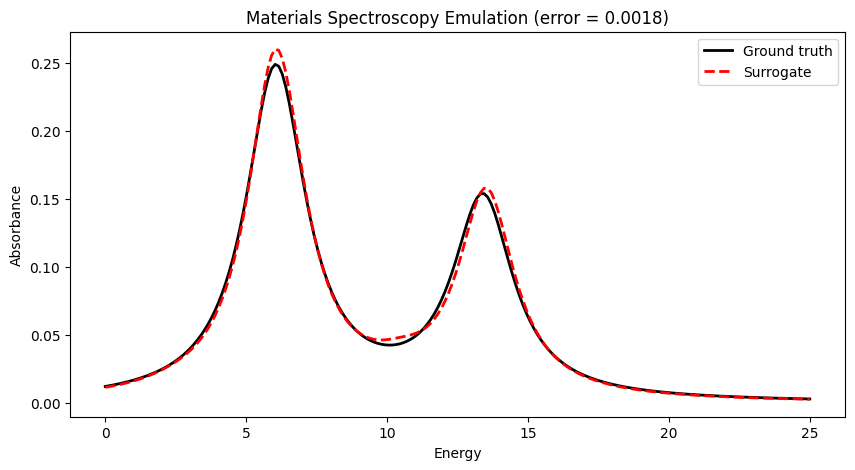

In [3]:
# Test point
test_params = np.array([0.35, 0.6])
truth = absorption_spectrum(test_params, energy)

# Train regression backend
# model = Surrogate('regression', n_components=3, width_mode='global', random_state=42)
model = Surrogate('pmm', n_poles=7)
model.fit(dataset)
result = model.predict(test_params, energy)
error = normalized_l2(result.spectrum, truth, energy)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(energy, truth, 'k-', lw=2, label='Ground truth')
ax.plot(energy, result.spectrum, 'r--', lw=2, label='Surrogate')
ax.set_xlabel('Energy')
ax.set_ylabel('Absorbance')
ax.set_title(f'Materials Spectroscopy Emulation (error = {error:.4f})')
ax.legend()

print(f"\nNormalized L2 error: {error:.4f}")
fig